**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Examen Final**

*Diciembre, 2025*




---


Nombre y Apellido: Alexander Ballera

---



Número de registro: 919064

---



---

## Observaciones Importantes

- **Librerías permitidas:** NumPy, Pandas, Matplotlib, SymPy, SciPy (Librerias complementarias consulte con el profesor)
- **Formato de entrega:** Jupyter Notebook (.ipynb) con código ejecutable y comentarios
- **Evaluación:** Se calificará código funcional, interpretación económica y calidad de visualizaciones
- **Redondeo:** Usar 2 decimales para valores monetarios, 4 para tasas porcentuales

---

**Abajo de esta línea, importá/instalá todas las *libraries* que consideres relevantes para la resolución de este examen.**

In [101]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy_financial as nf

In [102]:
# FUNCIONES ÚTILES QUE DECLARARÉ DE MANERA GLOBAL QUE PODRÉ REUTILIZAR EN LOS EJERCICIOS

# Valor máximo de los ejes de coordenadas para mejor visualización
def x_y_max (value, factor, eje):
    value = int(float(value))
    return value*factor if (eje == 'x') else (value + factor)

# Fórmula de Equivalencia
def tasa_equivalente(i_t1, t2, t1):
    return (1 + i_t1) ** (t2 / t1) - 1

# Período de recuperación descontado
def payback_desc(flujos, rate):
    acum_desc = 0
    prd = None
    inversion_inicial = abs(flujos[0])
    
    for t in range(1, len(flujos)):
        # Descontar el flujo de caja actual
        discounted_flow = flujos[t] / (1 + rate)**t
        acum_desc += discounted_flow

        # Verificar si el flujo de caja descontado acumulado es mayor o igual a la inversión inicial
        if acum_desc >= inversion_inicial:
            # Si es así, calcular el período de recuperación descontado
            remaining_investment = inversion_inicial - (acum_desc - discounted_flow)
            prd = t - 1 + (remaining_investment / discounted_flow)
            break
    
    return prd

## Ejercicio 1: Análisis de DataFrames y Operaciones Vectorizadas (25 pts)

Una cadena de supermercados analiza las ventas de 3 categorías de productos (Alimentos, Bebidas, Limpieza) durante 12 semanas. A continuación se presenta el DataFrame con los datos:

**a)** Tomando la base de datos ´datos_supermercado_simulados.csv´ Importe el DataFrame y explore:
- Mostrar las primeras 5 filas
- Verificar que no haya valores nulos
- Mostrar un resumen estadístico básico
- Interprete

In [103]:
# Exploración del DataFrame


**b)** Crear columnas adicionales:
- `ingreso_semanal`
- `margen_bruto`
- `rentabilidad_%`

**c)** Calcular:
- Ingreso total por categoría en todo el período
- Porcentaje de participación de cada categoría sobre el ingreso total
- Identificar la semana con mayor y menor rentabilidad

**d)** Definir una función `clasificar_desempeno(df)` que agregue una columna `estado` con:
- "Excelente" si rentabilidad_% ≥ 15%
- "Bueno" si 10% ≤ rentabilidad_% < 15%
- "Regular" si rentabilidad_% < 10%

Aplicar la función al DataFrame.

**e)** Crear dos gráficos:
- Gráfico de líneas: evolución del margen_bruto a lo largo de las semanas
- Gráfico de barras: participación porcentual de cada categoría en el ingreso total
- Interprete

---

## Ejercicio 2: Optimización con Derivadas (25 pts)

Una empresa tecnológica enfrenta las siguientes funciones económicas:

- **Demanda inversa:** $p(q) = 250 - 1.2q - 0.02q^2$
- **Costo Total:** $C(q) = 800 + 10q + 0.08q^2$

**a)** Definir simbólicamente (con SymPy):
- Función de Ingreso Total: $I(q)$
- Función de Beneficio Total: $B(q)$
- Función de Costo Medio: $C_{me}(q)$

**b)** Calcule:
- Ingreso Marginal: $I'(q)$
- Costo Marginal: $C'(q)$
- Derivada del Beneficio: $B'(q)$

**c)** Optimización:
- Hallar la cantidad que maximiza el beneficio
- Verificar con la segunda derivada que es un máximo
- Hallar precio óptimo e ingreso total óptimo

**d)** Elasticidad precio de la demanda:
- Obtener la expresión general: $\varepsilon = \frac{dQ}{dp} \cdot \frac{p}{Q}$
- Evaluar la elasticidad en $q = 50$ y clasificarla (elástica/inelástica/unitaria)

---

## Ejercicio 3: Integración y Excedentes Económicos (25 pts)

En un mercado se presentan las siguientes funciones:

- **Demanda:** $p_d(q) = 100 - 3q - 0.7q^2$
- **Oferta:** $p_s(q) = 25 + 1.8q$

**a)** Encontrar el equilibrio de mercado:
- Resolver $p_d(q) = p_s(q)$ para obtener $q^*$
- Calcular el precio de equilibrio $p^*$
- Verificar numéricamente el resultado

**b)** Calcular el Excedente del Consumidor (EC):
- Definir la integral: $EC = \int_0^{q^*} [p_d(q) - p^*] \, dq$
- Resolver simbólicamente con SymPy
- Evaluar numéricamente

**c)** Calcular el Excedente del Productor (EP):
- Definir la integral: $EP = \int_0^{q^*} [p^* - p_s(q)] \, dq$
- Resolver simbólicamente
- Evaluar numéricamente

**d)** Calcular el Bienestar Social Total e interpretar el significado economico

**e)** Grafique lo expuesto con anterioriedad e interprete

---

## Ejercicio 4: Análisis de Inversiones (VAN, TIR, TIRM) (25 pts)

Una empresa evalúa un proyecto de expansión con el siguiente flujo de fondos **MENSUAL**.

El costo de capital anual es del **12%**.

In [104]:
inversion_inicial = -85000

cash_flows = [
    14000, -9000, 17000, 20000, -11000, 23000, 26000, 29000, -14000, 32000,
    15000, -10000, 18000, 21000, 22000, -15000, 25000, 28000, 31000, -13000,
    16000, 21000, 24000, -12000, 27000, 30000, 33000, -16000, 34000, 36000
]

flujo_total = [inversion_inicial] + cash_flows
nuevo_cash_flow = flujo_total


In [105]:
# Tasa de descuento anual
TEA = 0.1200  # 12% anual

r = tasa_equivalente(TEA, 30, 365) # La fórmula está al inicio de esta notebook
print(f"Tasa efectiva mensual equivalente: TEA {TEA:.4%} → TEM {r:.4%}")

Tasa efectiva mensual equivalente: TEA 12.0000% → TEM 0.9358%


**a)** Calcular las métricas financieras básicas:
- Valor Actual Neto (VAN)
- Tasa Interna de Retorno (TIR)
- Tasa Interna de Retorno Modificada (TIRM) con tasa de reinversión = tasa de descuento
- Interpretar cada métrica

In [106]:
# VAN
van = nf.npv(r, nuevo_cash_flow)
print(f"Tasa de descuento mensual utilizada: {r:.4%}")
print(f"""
El proyecto genera un valor actual neto de ${van:,.2f}.

El VAN es mayor que cero (VAN>0). Esto implica que el proyecto creará valor para la empresa,
ya que el valor presente de todos los flujos de caja futuros supera la inversión inicial.
Segun el VAN el proyecto es rentable
""")

Tasa de descuento mensual utilizada: 0.9358%

El proyecto genera un valor actual neto de $291,515.96.

El VAN es mayor que cero (VAN>0). Esto implica que el proyecto creará valor para la empresa,
ya que el valor presente de todos los flujos de caja futuros supera la inversión inicial.
Segun el VAN el proyecto es rentable



In [107]:
# TIR
tir = nf.irr(values=nuevo_cash_flow)

tir_anual = tasa_equivalente(tir, 365, 30) 

print(f"TEM: {r:.4%}")
print(f"TIR mensual: {tir:.4%}")
print(f"TIR anual: {tir_anual:.4%}")
print(f'\nVIABLE: La TIR ({tir_anual:.4%}) supera el costo de capital ({TEA:.4%}).')
print('''
La TIR anualizada es mayor que r. Esto implica que el proyecto creará valor para
la empresa, ya que el valor implícito del proyecto según sus cash flows supera al
costo de capital exigido al proyecto. Segun la TIR comparándola con el costo de
capital se recomienda invertir en el proyecto.
      ''')

TEM: 0.9358%
TIR mensual: 13.4767%
TIR anual: 365.6197%

VIABLE: La TIR (365.6197%) supera el costo de capital (12.0000%).

La TIR anualizada es mayor que r. Esto implica que el proyecto creará valor para
la empresa, ya que el valor implícito del proyecto según sus cash flows supera al
costo de capital exigido al proyecto. Segun la TIR comparándola con el costo de
capital se recomienda invertir en el proyecto.
      


In [108]:
# TIRM
# finance_rate: costo de financiar flujos negativos (costo de capital) - USAR TIR
# reinvest_rate: tasa de reinversión de flujos positivos (costo de oportunidad) - USAR r

tirm = nf.mirr(values=nuevo_cash_flow, finance_rate=tir, reinvest_rate=r)

tirm_anual = tasa_equivalente(tirm, 365, 30)

print(f"TIRM mensual: {tirm:.4%}")
print(f"TEM: {r:.4%}")
print(f"TIRM anual: {tirm_anual:.4%}")

print(f"\nInterpretación: La rentabilidad modificada es {tirm_anual:.4%} anual.")
print("Es más conservadora que la TIR porque asume reinversión al costo de capital.")
print(f'VIABLE: La TIRM ({tirm_anual:.4%}) supera el costo de capital ({TEA:.4%}).')
print('''
La TIRM es mayor que r. Esto implica que el proyecto creará valor para la empresa,
Ya que el valor implícito del proyecto según sus cash flows supera al costo de
capital exigido al proyecto. Segun la TIR comparándola con el costo de capital se
recomienda invertir en el proyecto.
      ''')

TIRM mensual: 5.9374%
TEM: 0.9358%
TIRM anual: 101.7283%

Interpretación: La rentabilidad modificada es 101.7283% anual.
Es más conservadora que la TIR porque asume reinversión al costo de capital.
VIABLE: La TIRM (101.7283%) supera el costo de capital (12.0000%).

La TIRM es mayor que r. Esto implica que el proyecto creará valor para la empresa,
Ya que el valor implícito del proyecto según sus cash flows supera al costo de
capital exigido al proyecto. Segun la TIR comparándola con el costo de capital se
recomienda invertir en el proyecto.
      


**b)** Calcular el Período de Recuperación Descontado (PRD) e interprete


In [109]:
# Período de Recuperación Descontado (PRD)

prd = payback_desc(nuevo_cash_flow, r) # La fórmula está al inicio de esta notebook
print(f"Payback descontado: {prd:.2f} meses ({prd/12:.2f} años)" if prd is not None else "Payback descontado: No se recupera la inversión")

print(f'''
Interpretación del Período de Recuperación Descontado (PRD):

El PRD indica que la inversión inicial de ${-inversion_inicial} se recupera en {prd:.2f} meses
cuando se consideran los flujos de caja descontados a la tasa mensual del {r*100:.4f}%.

Análisis:

- Tiempo de recuperación: {prd:.2f} meses (aproximadamente {round(prd)} meses)
- Interpretación: Un PRD corto ({round(prd)} meses) indica bajo riesgo en el corto plazo,
                  ya que la inversión se recupera rápidamente, reduciendo la
                  exposición a incertidumbres futuras, sobre todo en entornos 
                  económicos de alta volatilidad.

Conclusión:

La empresa recupera su inversión inicial en menos de {prd:.2f} meses, lo que confirma que
el proyecto es factible desde la perspectiva de liquidez y rentabilidad en el corto plazo.
      ''')

Payback descontado: 7.32 meses (0.61 años)

Interpretación del Período de Recuperación Descontado (PRD):

El PRD indica que la inversión inicial de $85000 se recupera en 7.32 meses
cuando se consideran los flujos de caja descontados a la tasa mensual del 0.9358%.

Análisis:

- Tiempo de recuperación: 7.32 meses (aproximadamente 7 meses)
- Interpretación: Un PRD corto (7 meses) indica bajo riesgo en el corto plazo,
                  ya que la inversión se recupera rápidamente, reduciendo la
                  exposición a incertidumbres futuras, sobre todo en entornos 
                  económicos de alta volatilidad.

Conclusión:

La empresa recupera su inversión inicial en menos de 7.32 meses, lo que confirma que
el proyecto es factible desde la perspectiva de liquidez y rentabilidad en el corto plazo.
      


**c)** Análisis de sensibilidad:
- Graficar el VAN vs. diferentes tasas de descuento
- Marcar en el gráfico la TIR (donde VAN = 0)
- Marcar la tasa de descuento actual (12%)
- Interpretar el comportamiento de la curva

Tasa Interna de Retorno (TIR): 13.4767%
Tasa De Descuento (r): 0.9358%


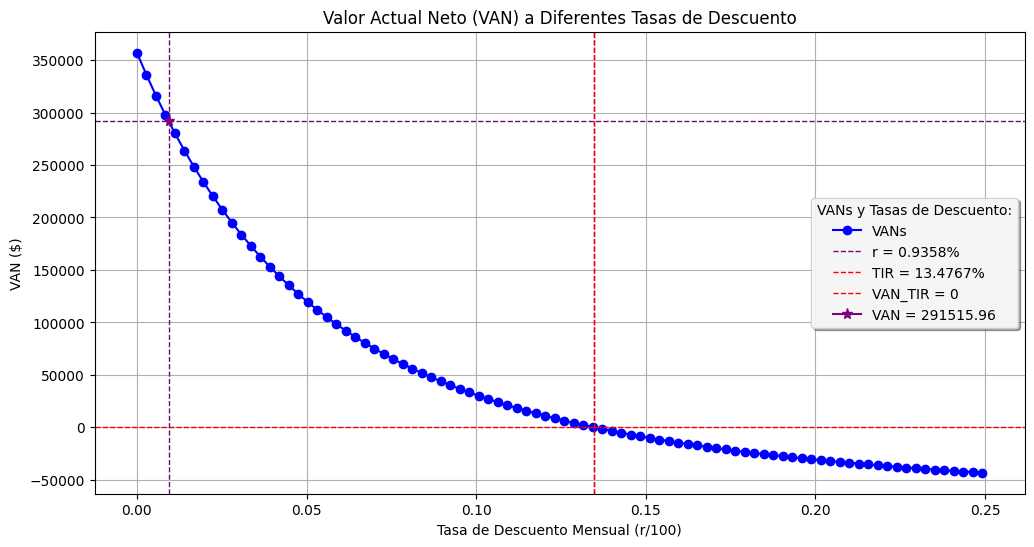

In [110]:
# Calcular TIR y TIRM
flujos = nuevo_cash_flow.copy()
van_tirm = nf.npv(tirm, nuevo_cash_flow)

print(f"Tasa Interna de Retorno (TIR): {tir:.4%}")
print(f"Tasa De Descuento (r): {r:.4%}")

# --- Crear rango de tasas para VAN ---
tasas_descuento = np.arange(0, max(tir*1.2, 0.25), 0.0028) # es muy importante agregar el max porque sino el grafico no encuentra el corte con la tir, queda desescalado.
# --- Calcular VAN para cada tasa ---
van_por_tasa = [nf.npv(tasa, flujos) for tasa in tasas_descuento]

# --- Graficar VAN vs Tasa ---
plt.figure(figsize=(12, 6))
plt.plot(tasas_descuento, van_por_tasa, marker='o', linestyle='-', color='blue', label='VANs')

# Marcar TIR y TIRM en el gráfico
plt.axvline(tir, color='purple', linestyle='--', linewidth=1, label=f"r = {r:.4%}")
plt.axvline(tir, color='red', linestyle='--', linewidth=1, label=f"TIR = {tir:.4%}")
plt.axhline(0, color='red', linestyle='--', linewidth=1, label="VAN_TIR = 0")
# plt.axvline(tirm, color='green', linestyle='--', linewidth=1, label=f"TIRM = {tirm:.2%}")
# plt.axhline(van_tirm, color='green', linestyle='--', linewidth=1, label=f"VAN_TIRM = {van_tirm:.2f}")

# grafico el punto del VAN del proyecto
plt.plot(r, van, marker='*', color='purple', markersize=8, label=f"VAN = {van:.2f}")
plt.axvline(r, color='purple', linestyle='--', linewidth=1)
plt.axhline(van, color='purple', linestyle='--', linewidth=1)

# --- Etiquetas y formato ---
plt.title('Valor Actual Neto (VAN) a Diferentes Tasas de Descuento')
plt.xlabel('Tasa de Descuento Mensual (r/100)')
plt.ylabel('VAN ($)')
plt.grid(True)
plt.legend(
    loc='best',
    shadow=True,
    fancybox=True,
    framealpha=0.9,
    title='VANs y Tasas de Descuento:',
    )
plt.show()

In [111]:
print(f'''
Análisis del Gráfico VANs vs Tasas de Descuento:**

El gráfico muestra la relación inversa entre el VAN y la tasa de descuento: a mayor tasa, menor VAN.
La curva cruza el eje horizontal (VAN=0) en el punto TIR = {tir*100:.4f}% mensual, que representa la tasa máxima
que el proyecto puede soportar antes de dejar de ser rentable.

Al evaluar el proyecto con la tasa de descuento del {r*100:.4f}% mensual (equivalente al {TEA*100:.4f}% anual),
el punto correspondiente en la curva del VAN (marcado en morado) se encuentra muy por encima de la línea horizontal de VAN=0,
generando un valor presente neto positivo de ${van:.2f}.

Conclusión: El gráfico confirma visualmente que el proyecto es altamente viable, ya que el VAN se mantiene positivo 
mientras la tasa de descuento sea inferior a {tir*100:.4f}% mensual. Con el costo de capital actual ({r*100:.4f}% mensual),
el proyecto genera valor económico y se recomienda invertir en el mismo.
    ''')


Análisis del Gráfico VANs vs Tasas de Descuento:**

El gráfico muestra la relación inversa entre el VAN y la tasa de descuento: a mayor tasa, menor VAN.
La curva cruza el eje horizontal (VAN=0) en el punto TIR = 13.4767% mensual, que representa la tasa máxima
que el proyecto puede soportar antes de dejar de ser rentable.

Al evaluar el proyecto con la tasa de descuento del 0.9358% mensual (equivalente al 12.0000% anual),
el punto correspondiente en la curva del VAN (marcado en morado) se encuentra muy por encima de la línea horizontal de VAN=0,
generando un valor presente neto positivo de $291515.96.

Conclusión: El gráfico confirma visualmente que el proyecto es altamente viable, ya que el VAN se mantiene positivo 
mientras la tasa de descuento sea inferior a 13.4767% mensual. Con el costo de capital actual (0.9358% mensual),
el proyecto genera valor económico y se recomienda invertir en el mismo.
    


**d)** Repita a) y b) para una tasa de descuento del 18% Anual y haga un gráfico comparativo:


In [112]:
# d.a Nueva TEA 18%, calculo nueva TEM, VAN, TIR, TIRM y PRD
TEA_2 = 0.18  # 18% anual
r2 = tasa_equivalente(TEA_2, 30, 365)  # Tasa efectiva mensual
print(f"Nueva TEA: {TEA_2:.4%} → Nueva TEM: {r2:.4%}")


Nueva TEA: 18.0000% → Nueva TEM: 1.3697%


In [113]:
# VAN2
van2 = nf.npv(rate=r2, values=nuevo_cash_flow)
print(f"Tasa de descuento mensual utilizada: {r2:.4%}")
print(f"""
El proyecto genera un valor actual neto de ${van2:,.2f}.

El VAN es mayor que cero (VAN>0). Esto implica que el proyecto creará valor para la empresa,
ya que el valor presente de todos los flujos de caja futuros supera la inversión inicial.
Segun el VAN el proyecto es rentable
""")

Tasa de descuento mensual utilizada: 1.3697%

El proyecto genera un valor actual neto de $265,494.45.

El VAN es mayor que cero (VAN>0). Esto implica que el proyecto creará valor para la empresa,
ya que el valor presente de todos los flujos de caja futuros supera la inversión inicial.
Segun el VAN el proyecto es rentable



In [114]:
# TIR2
tir2 = nf.irr(values=nuevo_cash_flow)  # TIR no cambia (característica del proyecto)

tir2_anual = tasa_equivalente(tir2, 365, 30) 

print(f"TEM2: {r2:.4%}")
print(f"TIR2 mensual: {tir2:.4%}")
print(f"TIR2 anual: {tir2_anual:.4%}")
print(f'\nVIABLE: La TIR2 ({tir2_anual:.4%}) supera el costo de capital ({TEA:.4%}).')
print('''
La TIR no se ve afectada por el cambio en el costo de capital, ya que
la TIR es una tasa interna de retorno que depende únicamente de los flujos
de caja del proyecto, mide el valor intrínseco del proyecto independientemente
del costo de financiamiento. Segun la TIR comparándola con el costo de capital
se recomienda invertir en el proyecto.
      ''')

TEM2: 1.3697%
TIR2 mensual: 13.4767%
TIR2 anual: 365.6197%

VIABLE: La TIR2 (365.6197%) supera el costo de capital (12.0000%).

La TIR no se ve afectada por el cambio en el costo de capital, ya que
la TIR es una tasa interna de retorno que depende únicamente de los flujos
de caja del proyecto, mide el valor intrínseco del proyecto independientemente
del costo de financiamiento. Segun la TIR comparándola con el costo de capital
se recomienda invertir en el proyecto.
      


In [115]:
# TIRM2

# finance_rate: costo de financiar flujos negativos (costo de capital) - USAR TIR
# reinvest_rate: tasa de reinversión de flujos positivos (costo de oportunidad) - USAR r

tirm2 = nf.mirr(values=nuevo_cash_flow, finance_rate=tir2, reinvest_rate=r2)
tirm2_anual = tasa_equivalente(tirm2, 365, 30)

print(f"TIRM mensual: {tirm2:.4%}")
print(f"TEM: {r2:.4%}")
print(f"TIRM anual: {tirm2_anual:.4%}")

print(f"\nInterpretación: La rentabilidad modificada es {tirm2_anual:.4%} anual.")
print("Es más conservadora que la TIR porque asume reinversión al costo de capital.")
print(f'VIABLE: La TIRM ({tirm2_anual:.4%}) supera el costo de capital ({TEA:.4%}).')
print('''
La TIRM es mayor que r. Esto implica que el proyecto creará valor para la empresa,
Ya que el valor implícito del proyecto según sus cash flows supera al costo de
capital exigido al proyecto. A pesar de aumentar el costo de capital, la TIRM2 sigue
siendo mayor que r, con lo que se recomienda invertir en el proyecto.
      ''')

TIRM mensual: 6.1447%
TEM: 1.3697%
TIRM anual: 106.5841%

Interpretación: La rentabilidad modificada es 106.5841% anual.
Es más conservadora que la TIR porque asume reinversión al costo de capital.
VIABLE: La TIRM (106.5841%) supera el costo de capital (12.0000%).

La TIRM es mayor que r. Esto implica que el proyecto creará valor para la empresa,
Ya que el valor implícito del proyecto según sus cash flows supera al costo de
capital exigido al proyecto. A pesar de aumentar el costo de capital, la TIRM2 sigue
siendo mayor que r, con lo que se recomienda invertir en el proyecto.
      


In [116]:
# Período de Recuperación Descontado (PRD) 2

prd2 = payback_desc(nuevo_cash_flow, r2) # La fórmula está al inicio de esta notebook
print(f"Payback descontado: {prd2:.2f} meses ({prd2/12:.2f} años)" if prd2 is not None else "Payback descontado: No se recupera la inversión")

print(f'''
Interpretación del Período de Recuperación Descontado (PRD):

El PRD indica que la inversión inicial de ${-inversion_inicial} se recupera en {prd2:.2f} meses
cuando se consideran los flujos de caja descontados a la tasa mensual del {r2*100:.4f}%.

Análisis:

- Tiempo de recuperación: {prd2:.2f} meses (aproximadamente {round(prd2)} meses)
- Interpretación: Un PRD corto ({round(prd2)} meses) indica bajo riesgo en el corto plazo,
                  ya que la inversión se recupera rápidamente, reduciendo la
                  exposición a incertidumbres futuras, sobre todo en entornos 
                  económicos de alta volatilidad.

Conclusión:

La empresa recupera su inversión inicial en menos de {prd2:.2f} meses, lo que confirma que
el proyecto es factible desde la perspectiva de liquidez y rentabilidad en el corto plazo.
      ''')

Payback descontado: 7.39 meses (0.62 años)

Interpretación del Período de Recuperación Descontado (PRD):

El PRD indica que la inversión inicial de $85000 se recupera en 7.39 meses
cuando se consideran los flujos de caja descontados a la tasa mensual del 1.3697%.

Análisis:

- Tiempo de recuperación: 7.39 meses (aproximadamente 7 meses)
- Interpretación: Un PRD corto (7 meses) indica bajo riesgo en el corto plazo,
                  ya que la inversión se recupera rápidamente, reduciendo la
                  exposición a incertidumbres futuras, sobre todo en entornos 
                  económicos de alta volatilidad.

Conclusión:

La empresa recupera su inversión inicial en menos de 7.39 meses, lo que confirma que
el proyecto es factible desde la perspectiva de liquidez y rentabilidad en el corto plazo.
      


---

In [117]:
# Creo un cuadro comparativo de métricas financieras
comparacion_data = {
    'Métrica': ['VAN', 'TIR', 'TIRM', 'PBD (meses)'],
    f'TEA {TEA*100:.4f}% anual': [f"${van:,.2f}", f"{tir:.2%}", f"{tirm:.2%}", f"{prd:.2f} meses"],
    f'TEA {TEA_2*100:.4f}% anual': [f"${van2:,.2f}", f"{tir2:.2%}", f"{tirm2:.2%}", f"{prd2:.2f} meses"],
    'Diferencia': [f"${van - van2:,.2f}", "Sin cambio", f"{tirm2 - tirm:.2%}", f"{prd2 - prd:.2f} meses"]
}

df_comparacion = pd.DataFrame(comparacion_data)
print("CUADRO COMPARATIVO DE MÉTRICAS FINANCIERAS")
print("=" * 60)
print(df_comparacion.to_string(index=False))


CUADRO COMPARATIVO DE MÉTRICAS FINANCIERAS
    Métrica TEA 12.0000% anual TEA 18.0000% anual Diferencia
        VAN        $291,515.96        $265,494.45 $26,021.51
        TIR             13.48%             13.48% Sin cambio
       TIRM              5.94%              6.14%      0.21%
PBD (meses)         7.32 meses         7.39 meses 0.07 meses


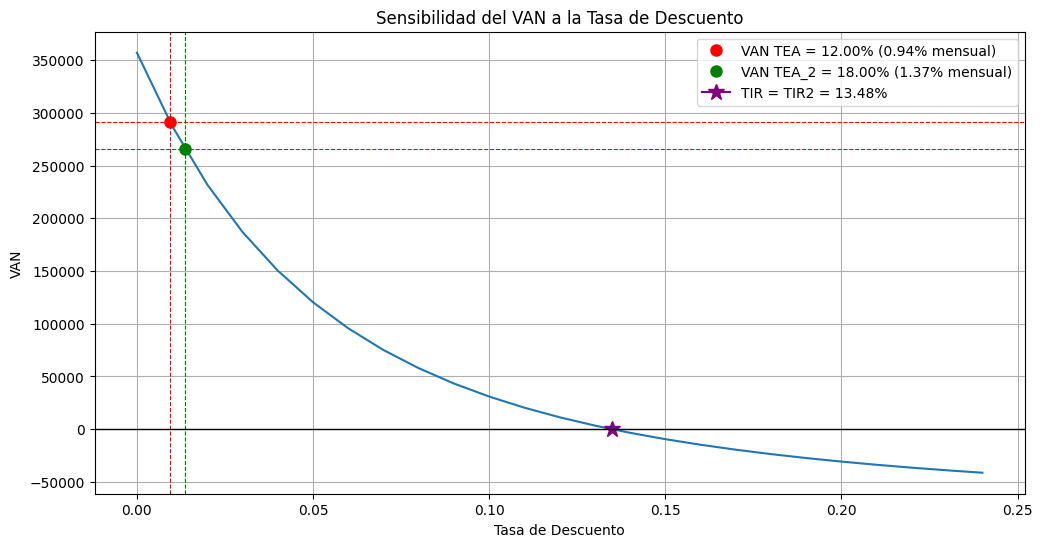

In [118]:
# Gráfico comparativo de ambos escenarios

# Definimos rango de tasas de descuento
tasas_rango = np.arange(0, 0.25, 0.01)

# Calculamos VAN para cada tasa
van_proyecto_rango = [nf.npv(tasa, nuevo_cash_flow) for tasa in tasas_rango]

# Creo el grafico
plt.figure(figsize=(12, 6))
plt.plot(tasas_rango, van_proyecto_rango, linestyle='-')

# Marcar VAN
plt.plot(r, van, 'ro', markersize=8, label=f'VAN TEA = {TEA*100:.2f}% ({r*100:.2f}% mensual)')
plt.axvline(r, color='red', linestyle='--', linewidth=0.8)
plt.axhline(van, color='red', linestyle='--', linewidth=0.8)
plt.plot(r2, van2, 'go', markersize=8, label=f'VAN TEA_2 = {TEA_2*100:.2f}% ({r2*100:.2f}% mensual)')
plt.axvline(r2, color='green', linestyle='--', linewidth=0.8)
plt.axhline(van2, color='green', linestyle='--', linewidth=0.8)

# Marcar TIR
plt.plot(tir, 0, color='purple', markersize=12, marker='*', label=f'TIR = TIR2 = {tir:.2%}') # Mostrar la TIR

plt.title('Sensibilidad del VAN a la Tasa de Descuento')
plt.xlabel('Tasa de Descuento')
plt.ylabel('VAN')


plt.grid(True)
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.legend()
plt.show()

In [119]:
print('''
Interpretación del Gráfico de Sensibilidad del VAN a la Tasa de Descuento:

El gráfico ilustra cómo el VAN del proyecto disminuye a medida que aumenta la tasa de descuento.
A medida que la tasa de descuento se incrementa, el valor presente de los flujos de caja futuros
disminuye, lo que reduce el VAN. El punto donde la curva cruza el eje horizontal (VAN=0)
corresponde a la TIR del proyecto, que permanece constante independientemente del costo de capital.

El cambio en la tasa de descuento de {TEA*100:.4f}% anual a {TEA_2*100:.4f}% anual no afecta la factibilidad
del proyecto, ya que ambas tasas se encuentran por debajo de la TIR. Por lo tanto, la recomendación
es continuar con la inversión en el proyecto.
''')


Interpretación del Gráfico de Sensibilidad del VAN a la Tasa de Descuento:

El gráfico ilustra cómo el VAN del proyecto disminuye a medida que aumenta la tasa de descuento.
A medida que la tasa de descuento se incrementa, el valor presente de los flujos de caja futuros
disminuye, lo que reduce el VAN. El punto donde la curva cruza el eje horizontal (VAN=0)
corresponde a la TIR del proyecto, que permanece constante independientemente del costo de capital.

El cambio en la tasa de descuento de {TEA*100:.4f}% anual a {TEA_2*100:.4f}% anual no afecta la factibilidad
del proyecto, ya que ambas tasas se encuentran por debajo de la TIR. Por lo tanto, la recomendación
es continuar con la inversión en el proyecto.

